In [1]:
import os, sys
sys.path.append(r'/Users/khcho/Desktop/IRIS-moss-main/iris2plus/iris_lmsalpy')

import joblib
import gzip, pickle
import matplotlib.pyplot as plt
import glob, os, pdb
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.io import readsav
from scipy import stats, integrate
import xarray as xr
xr.set_options(keep_attrs=True)
import astropy.time as time 
import h5py, pickle, cdflib

plt.rcParams["image.origin"] = 'lower'
plt.rcParams["image.interpolation"] = 'none'
plt.rcParams["image.aspect"] = 'auto'

# Load the joblib file
file_path = '/Users/khcho/Desktop/IRIS-moss-main'
save_path = '/Users/khcho/Desktop/IRIS-moss-main/simulation'
os.chdir(file_path)

In [2]:
# 'E2':'15Mm_1MK_10kev_plage'
# 'E2+':'15Mm_1MK_10kev_plage_1.e25'
# 'E3':'15Mm_1MK_15kev_plage'
# 'E3+':'15Mm_1MK_15kev_plage_1.e25'
# 'E1':'15Mm_1MK_5kev_plage'
# 'E1+':'15Mm_1MK_5kev_plage_1.e25'
# 'E6':'15Mm_1MK_plage_10keV_20s_pauses_0.6f9'
# 'H2':'15Mm_1MK_plage_10keV_30sTC_1.2f9_corrected'
# 'E4':'15Mm_1MK_plage_10keV_30s_0.4f9'
# 'H1':'15Mm_1MK_plage_10keV_TC_1.2f9'
# 'E5':'15Mm_1MK_plage_15keV_30s_1.2f9'
# 'C1':'15Mm_1MK_th_plage_new_tdheat'
# 'C1+':'15mm_1MK_th_plage_1.e25'

In [3]:
models = ['E2', 'E2+', 'E3', 'E3+', 'E1', 'E1+', 'E6', 'H2', 'E4', 'H1', 'E5', 'C1', 'C1+']
radyn_model = xr.Dataset(
    data_vars=dict(
      data_path=('model', 
                 ['/Users/khcho/Desktop/IRIS-moss-main/simulation/rh_output_kh/15Mm_1MK_10kev_plage', 
                  '/Users/khcho/Desktop/IRIS-moss-main/simulation/rh_output_kh/15Mm_1MK_10kev_plage_1.e25', 
                  '/Users/khcho/Desktop/IRIS-moss-main/simulation/rh_output_kh/15Mm_1MK_15kev_plage', 
                  '/Users/khcho/Desktop/IRIS-moss-main/simulation/rh_output_kh/15Mm_1MK_15kev_plage_1.e25', 
                  '/Users/khcho/Desktop/IRIS-moss-main/simulation/rh_output_kh/15Mm_1MK_5kev_plage', 
                  '/Users/khcho/Desktop/IRIS-moss-main/simulation/rh_output_kh/15Mm_1MK_5kev_plage_1.e25', 
                  '/Users/khcho/Desktop/IRIS-moss-main/simulation/rh_output_kh/15Mm_1MK_plage_10keV_20s_pauses_0.6f9', 
                  '/Users/khcho/Desktop/IRIS-moss-main/simulation/rh_output_kh/15Mm_1MK_plage_10keV_30sTC_1.2f9_corrected', 
                  '/Users/khcho/Desktop/IRIS-moss-main/simulation/rh_output_kh/15Mm_1MK_plage_10keV_30s_0.4f9', 
                  '/Users/khcho/Desktop/IRIS-moss-main/simulation/rh_output_kh/15Mm_1MK_plage_10keV_TC_1.2f9', 
                  '/Users/khcho/Desktop/IRIS-moss-main/simulation/rh_output_kh/15Mm_1MK_plage_15keV_30s_1.2f9', 
                  '/Users/khcho/Desktop/IRIS-moss-main/simulation/rh_output_kh/15Mm_1MK_th_plage_new_tdheat', 
                  '/Users/khcho/Desktop/IRIS-moss-main/simulation/rh_output_kh/15mm_1MK_th_plage_1.e25'], 
                ), 
        z=(['model', 'zindex', 'time'], np.full([len(models), 300, 120], np.nan)), 
        temperature=(['model', 'zindex', 'time'], np.full([len(models), 300, 120], np.nan)), 
        vz=(['model', 'zindex', 'time'], np.full([len(models), 300, 120], np.nan)),
        n_e=(['model', 'zindex', 'time'], np.full([len(models), 300, 120], np.nan)), 
        log_tau=(['model', 'zindex', 'time'], np.full([len(models), 300, 120], np.nan)), 
        si_peak_ind=(['model'], np.full(len(models), np.nan)),
    ),
    coords = dict(
        model=models, 
        zindex=np.arange(300), 
        time=np.arange(120), 
    ),
)

In [4]:
# IDL_savefile = radyn_model.sel(model=model).data_path.values+'/si_iv_fit_res.sav'
si_iv_fit = readsav('/Users/khcho/Desktop/IRIS-moss-main/simulation/sim_res.sav')  
model_name0 = [str(i[3], encoding='utf-8') for i in si_iv_fit['sim_res']]
model_peak_ind0 = [i[2] for i in si_iv_fit['sim_res']]

sim_files = glob.glob('/Users/khcho/Desktop/IRIS-moss-main/simulation/sims_for_kyu/**/*.cdf', 
                      recursive=True)
sim_dir = [sim_file.split('/')[-2] for sim_file in sim_files]

In [5]:
if True:
    xr_var_name = ['z', 'temperature', 'vz', 'n_e', 'log_tau']
    cdf_var_name = ['z1', 'tg1', 'vz1', 'ne1', 'tau']
    for i, model in enumerate(radyn_model.model.values):
        loc = model_name0.index(model)
        peak_ind0 = model_peak_ind0[loc]
        sim_file = [k for k in sim_files if (model in k)]
        if len(sim_file) > 1: 
            sim_file = [item for item in sim_file if '+' not in item][0]
        else:
            sim_file = sim_file[0]
        cdf_file = cdflib.CDF(sim_file)
        for j, name in enumerate(xr_var_name):
            radyn_model[xr_var_name[j]].loc[model:model] = xr.DataArray(
                cdf_file.varget(cdf_var_name[j])[:120], 
                dims=('time', 'zindex'), 
            )
        print(model, model_name0[loc], sim_file, peak_ind0)
        radyn_model['si_peak_ind'].loc[model:model] = peak_ind0
    radyn_model['log_tau'] = np.log10(radyn_model['log_tau'])        
    radyn_model['vz'] = radyn_model['vz']*1e-5
    radyn_model.to_zarr(save_path+'/RADYN_atm_model.zarr', mode='w')
else:
    radyn_model = xr.open_zarr(save_path+'/RADYN_atm_model.zarr').compute()

E2 E2 /Users/khcho/Desktop/IRIS-moss-main/simulation/sims_for_kyu/E2/radyn_out.cdf 10
E2+ E2+ /Users/khcho/Desktop/IRIS-moss-main/simulation/sims_for_kyu/E2+/radyn_out.cdf 6
E3 E3 /Users/khcho/Desktop/IRIS-moss-main/simulation/sims_for_kyu/E3/radyn_out.cdf 10
E3+ E3+ /Users/khcho/Desktop/IRIS-moss-main/simulation/sims_for_kyu/E3+/radyn_out.cdf 10
E1 E1 /Users/khcho/Desktop/IRIS-moss-main/simulation/sims_for_kyu/E1/radyn_out.cdf 2
E1+ E1+ /Users/khcho/Desktop/IRIS-moss-main/simulation/sims_for_kyu/E1+/radyn_out.cdf 1
E6 E6 /Users/khcho/Desktop/IRIS-moss-main/simulation/sims_for_kyu/E6-15Mm_1MK_10keV_plage_20s_pauses_0.6f9/radyn_out.cdf 20
H2 H2 /Users/khcho/Desktop/IRIS-moss-main/simulation/sims_for_kyu/H2-15Mm_1MK_10keV_plageTC_30s_corrected/radyn_out.cdf 6
E4 E4 /Users/khcho/Desktop/IRIS-moss-main/simulation/sims_for_kyu/E4-15Mm_1MK_10keV_plage_30s_0.4f9/radyn_out.cdf 30
H1 H1 /Users/khcho/Desktop/IRIS-moss-main/simulation/sims_for_kyu/H1-15Mm_1MK_10keV_plageTC/radyn_out.cdf 6
E5 E5 /

/Users/khcho/miniforge3/envs/iris2plus/lib/python3.12/site-packages/xarray/core/computation.py:818: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)


C1h


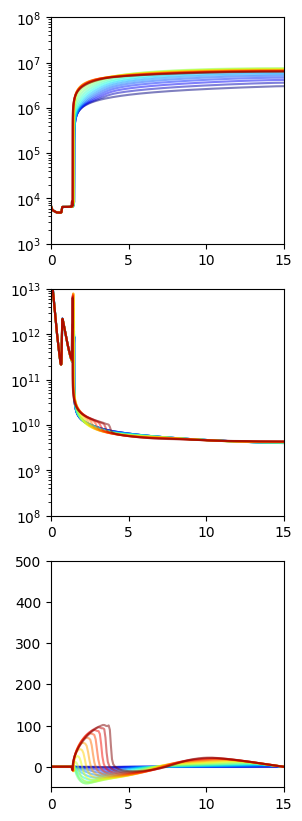

In [51]:
fig, ax = plt.subplots(3, 1, figsize=(3, 10))
model0 = radyn_model.model[12].values
model0 = 'C1h'
print(model0)
colors = plt.cm.jet(np.linspace(0, 1, 20))
for ii, t0 in enumerate(radyn_model.time[0:20]):
    ax[0].plot(radyn_model.z.sel(model=model0, time=t0)*1e-8, 
             radyn_model.temperature.sel(model=model0, time=t0), 
             color=colors[ii], alpha=0.5)
    ax[1].plot(radyn_model.z.sel(model=model0, time=t0)*1e-8, 
             radyn_model.n_e.sel(model=model0, time=t0), 
             color=colors[ii], alpha=0.5)
    ax[2].plot(radyn_model.z.sel(model=model0, time=t0)*1e-8, 
             radyn_model.vz.sel(model=model0, time=t0), 
             color=colors[ii], alpha=0.5)
    
    ax[0].set(yscale='log', ylim=[1e3, 1e8], xlim=[0, 15])    
    ax[1].set(yscale='log', ylim=[1e8, 1e13], xlim=[0, 15])    
    ax[2].set(ylim=[-50, 500], xlim=[0, 15])    

In [28]:
xr_var_name = ['z', 'temperature', 'vz', 'n_e', 'log_tau']
cdf_var_name = ['z1', 'tg1', 'vz1', 'ne1', 'tau']

new_dir = sorted(glob.glob('/Users/khcho/Desktop/IRIS-moss-main/simulation/sims_for_kyu2/combined/sims_kyuh/*'))

models = ['E2-', 'E3-', 'E1-', 'E2h', 'E3h', 'E1h', 'C1h']
radyn_model2 = xr.Dataset(
    data_vars=dict(
      data_path=('model', new_dir),
        z=(['model', 'zindex', 'time'], np.full([len(models), 300, 120], np.nan)), 
        temperature=(['model', 'zindex', 'time'], np.full([len(models), 300, 120], np.nan)), 
        vz=(['model', 'zindex', 'time'], np.full([len(models), 300, 120], np.nan)),
        n_e=(['model', 'zindex', 'time'], np.full([len(models), 300, 120], np.nan)), 
        log_tau=(['model', 'zindex', 'time'], np.full([len(models), 300, 120], np.nan)), 
        si_peak_ind=(['model'], np.full(len(models), np.nan)),
    ),
    coords = dict(
        model=models, 
        zindex=np.arange(300), 
        time=np.arange(120), 
    ),
)

for i, ndir in enumerate(new_dir):
    si_file = glob.glob(ndir+'/sp_si4_*Mm*MK*.save')[0]
    radyn_file = glob.glob(ndir+'/radyn_out.cdf')[0]
    si_data = readsav(si_file)
    wv_part = (si_data['wvl'] < (1402.77+1)) & (si_data['wvl'] > (1402.77-1))
    si_curve = np.sum(si_data['sp_time'][:, wv_part], axis=1)
    radyn_model2['si_peak_ind'].loc[{'model':models[i]}] = si_data['time'][np.argmax(si_curve)]

    cdf_file = cdflib.CDF(radyn_file)
    for j, name in enumerate(xr_var_name):
        radyn_model2[xr_var_name[j]].loc[{'model':models[i]}] = xr.DataArray(
            cdf_file.varget(cdf_var_name[j])[:120], 
            dims=('time', 'zindex'), 
        )
radyn_model2['log_tau'] = np.log10(radyn_model2['log_tau'])   
radyn_model2['vz'] = radyn_model2['vz']*1e-5
# radyn_model2.to_zarr(save_path+'/RADYN_atm_model2.zarr', mode='w')

radyn_model = xr.concat([radyn_model, radyn_model2], dim='model')
radyn_model.to_zarr(save_path+'/RADYN_atm_model.zarr', mode='w')



/Users/khcho/miniforge3/envs/iris2plus/lib/python3.12/site-packages/xarray/core/computation.py:818: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)


In [39]:
cdf_file.varget('qtotzt').shape

(603, 300)

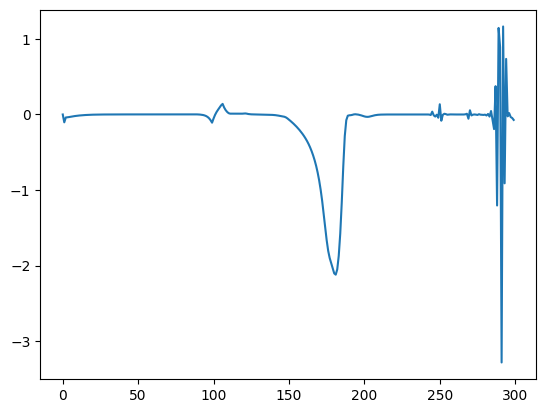

In [43]:
plt.plot(cdf_file.varget('qtotzt')[1])

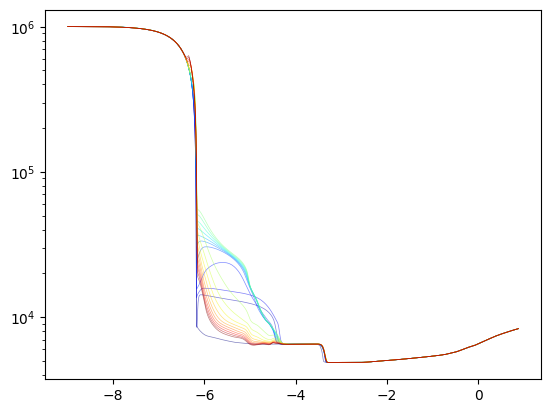

In [17]:
colors = plt.cm.jet(np.linspace(0, 1, 21))
for j, delt in enumerate(np.arange(-10, 11)):
    dum = radyn_model2.sel(model=f'E2-')
    plt.plot(dum.log_tau.sel(time=dum.si_peak_ind+delt), 
             dum.temperature.sel(time=dum.si_peak_ind+delt), 
             c=colors[j], lw=0.5, alpha=0.5)
    plt.gca().set(yscale='log')

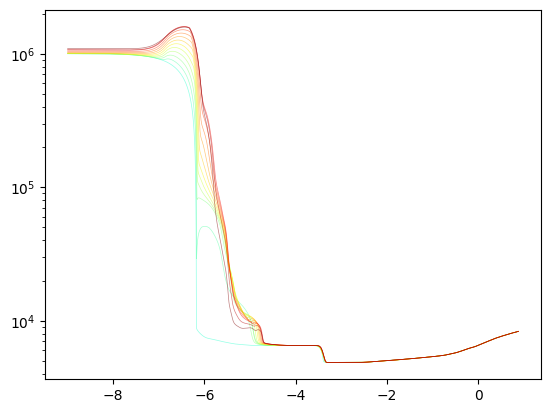

In [21]:
colors = plt.cm.jet(np.linspace(0, 1, 21))
for j, delt in enumerate(np.arange(-10, 11)):
    dum = radyn_model2.sel(model=f'E1-')
    if dum.time.sel(time=dum.si_peak_ind)+delt < 0: continue
    plt.plot(dum.log_tau.sel(time=dum.si_peak_ind+delt), 
             dum.temperature.sel(time=dum.si_peak_ind+delt), 
             c=colors[j], lw=0.5, alpha=0.5)
    plt.gca().set(yscale='log')

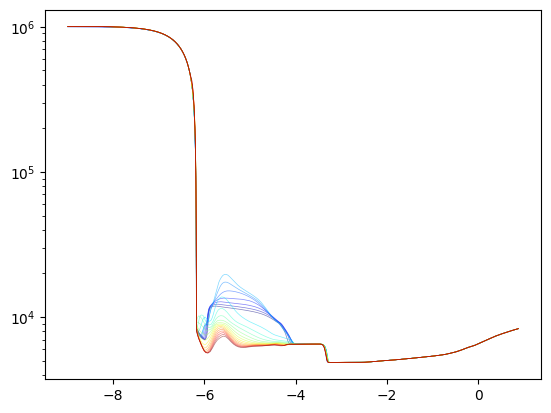

In [22]:
colors = plt.cm.jet(np.linspace(0, 1, 21))
for j, delt in enumerate(np.arange(-10, 11)):
    dum = radyn_model2.sel(model=f'E3-')
    if dum.time.sel(time=dum.si_peak_ind)+delt < 0: continue
    plt.plot(dum.log_tau.sel(time=dum.si_peak_ind+delt), 
             dum.temperature.sel(time=dum.si_peak_ind+delt), 
             c=colors[j], lw=0.5, alpha=0.5)
    plt.gca().set(yscale='log')

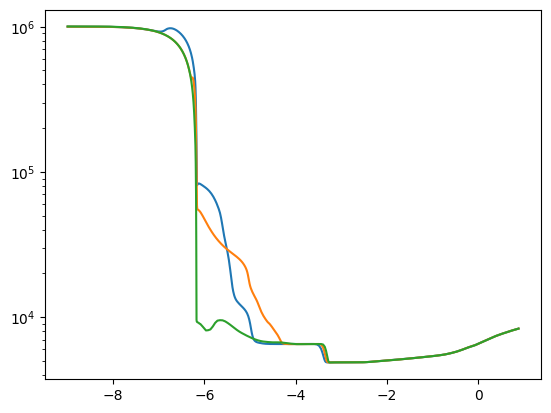

In [10]:
for i in range(1, 4):
    dum = radyn_model2.sel(model=f'E{i}-')
    plt.plot(dum.log_tau.sel(time=dum.si_peak_ind), dum.temperature.sel(time=dum.si_peak_ind))
    plt.gca().set(yscale='log')

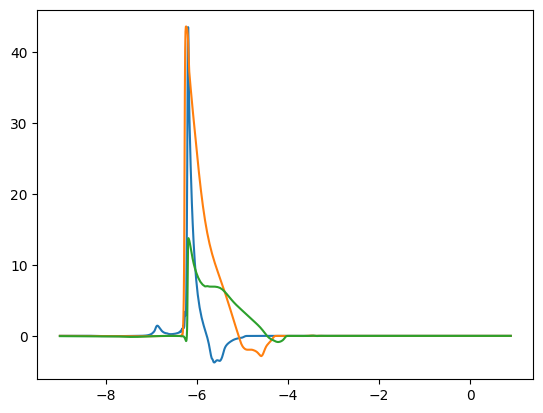

In [107]:
for i in range(1, 4):
    dum = radyn_model2.sel(model=f'E{i}-')
    plt.plot(dum.log_tau.sel(time=dum.si_peak_ind), dum.vz.sel(time=dum.si_peak_ind))
    # plt.gca().set(yscale='log')

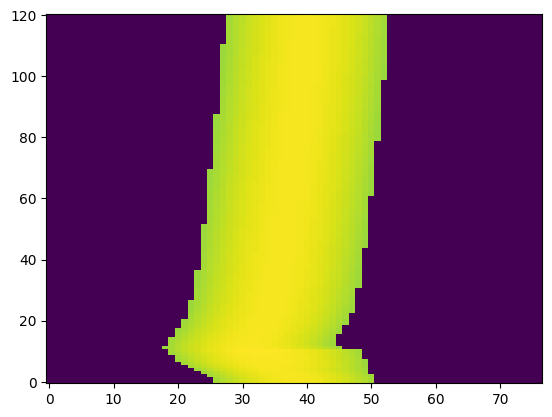

In [3]:

dum = readsav('/Users/khcho/Desktop/IRIS-moss-main/simulation/sims_for_kyu2/combined/sims_kyuh/15Mm_1MK_5kev_1.e24/sp_si4_0.026_15Mm_1MK_5kev_1.e24.save')

In [9]:
for i in dum.keys():
    print(i, dum[i].shape)


sp_time (121, 308)
time (121,)
dn ()
wvl (308,)


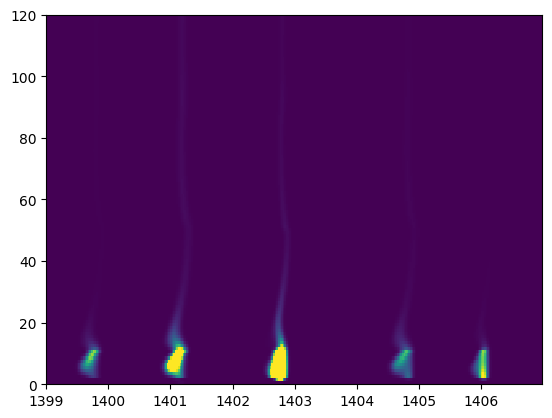

In [21]:
plt.imshow(dum['sp_time'], extent=[dum['wvl'][0], dum['wvl'][-1], dum['time'][0], dum['time'][-1]], 
           vmin=0, vmax=1e1)

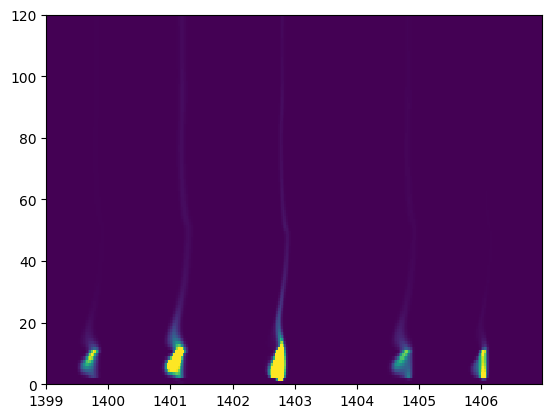

In [29]:
plt.imshow(aaa['sp_time'], extent=[aaa['wvl'][0], aaa['wvl'][-1], aaa['time'][0], aaa['time'][-1]], 
           vmin=0, vmax=1e1)

In [7]:
simulation = {'name':'', 'path':'', 
              'Si_wv':0, 'Si_t':0, 'Si_spec':0, 'Si_max_t':0,
              'Mg_wv':0, 'Mg_t':0, 'Mg_spec':0, 
              'ltau_500':0, 'height':0, 'temperature':0, 'vz':0
             }
simulations = [simulation for _ in sim_dir]

In [27]:
# this is using RH output, which is little bit difference from the result of RADYN... 

for i, sdir in enumerate(sim_dir):
    model = sdir[:3]
    if model[-1] == '-': model = model[:-1]
    print(model, sdir)    

    spec_dir = radyn_model.data_path.sel(model=model).item()
    si_file = glob.glob(spec_dir+'/sp_si4_*.save')[0]
    si_data = readsav(si_file)
    # ['sp_time', 'time', 'dn', 'wvl']
    si_wv0 = si_data['wvl']
    si_wv_ind = (si_wv0 > 1401.77) & (si_wv0 <1403.77)
    si_wv = si_wv0[si_wv_ind]
    si_t = np.arange(42)
    si_spec = si_data['sp_time'][:42][:, si_wv_ind]
    si_tot_int = np.sum(si_spec, axis=1)
    si_max_ind = np.argmax(si_tot_int)

    indata = h5py.File(spec_dir+'/output/output_indata.ncdf', 'r')
    # ['input', 'atmos', 'mpi', 'nx', 'ny', 'nz', 'strlen']
    ray = h5py.File(spec_dir+'/output/output_ray.ncdf', 'r')
    # ['nx', 'ny', 'nz', 'nwave', 'wavelength_selected', 'intensity', 'tau_one_height', 'chi', 
    #  'source_function', 'Jlambda', 'scattering', 'wavelength', 'wavelength_indices']
    
    mg_wv0 = np.array(ray['wavelength'])
    mg_intensity = np.squeeze(ray['intensity'])
    mg_wv_ind = (mg_wv0 > 279.5) & (mg_wv0 < 280.5)
    mg_wv = mg_wv0[mg_wv_ind]
    mg_t0 = np.arange(len(indata['nx']))
    mg_t_ind = mg_t0 < 42
    mg_t = mg_t0[mg_t_ind]
    mg_spec = mg_intensity[mg_t_ind][:, mg_wv_ind]
    
    wavelength_indices = np.array(ray['wavelength_indices'])
    wavelength_selected = np.array(ray['wavelength'])[wavelength_indices]
    idx_500 = np.argmin(abs(wavelength_selected - 500))
    if (wavelength_selected[idx_500] - 500) > 1:
        print('No wavelength near 500 nm')
    chi_500 = np.array(ray['chi'])[:, 0, :, idx_500]

    height0 = np.array((indata['atmos']['height']))[:, 0, :]
    height = np.where(height0 > 1e36, np.nan, height0)
    height1 = np.copy(height0)
    for ii, he in enumerate(height1):
        h_real = height0[ii][height0[ii] < 1e36]
        height1[ii] = np.where(height0[ii] > 1e36, 2*h_real[0]-h_real[1], height0[ii])

    tau_500 = integrate.cumulative_trapezoid(chi_500, x=-height1, initial=0)
    log_tau_500 = np.log10(tau_500)
    temperature = indata['atmos']['temperature'][:, 0, :]
    temperature = np.where(temperature > 1e35, np.nan, temperature)
    velocity_z = indata['atmos']['velocity_z'][:, 0, :]
    velocity_z = np.where(velocity_z > 1e35, np.nan, velocity_z)
    simulations[i]['name'] = name
    simulations[i]['path'] = sdir
    simulations[i]['Si_wv'] = si_wv
    simulations[i]['Si_t'] = si_t
    simulations[i]['Si_spec'] = si_spec
    simulations[i]['Si_max_t'] = si_max_ind
    simulations[i]['Mg_wv'] = mg_wv
    simulations[i]['Mg_t'] = mg_t
    simulations[i]['mg_spec'] = mg_spec
    simulations[i]['log_tau_500'] = log_tau_500
    simulations[i]['height'] = height
    simulations[i]['temperature'] = temperature
    simulations[i]['vz'] = velocity_z
with open(save_path+'/simulations.pickle', 'wb') as fp:
    pickle.dump(simulations, fp)    


H2 H2-15Mm_1MK_10keV_plageTC_30s_corrected


FileNotFoundError: [Errno 2] Unable to open file (unable to open file: name = 'H2-15Mm_1MK_10keV_plageTC_30s_corrected/output/output_indata.ncdf', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [29]:
spec_dir

'/Users/khcho/Desktop/IRIS-moss-main/simulation/rh_output_kh/15Mm_1MK_plage_10keV_30sTC_1.2f9_corrected'

15Mm_1MK_th_plage_new_tdheat


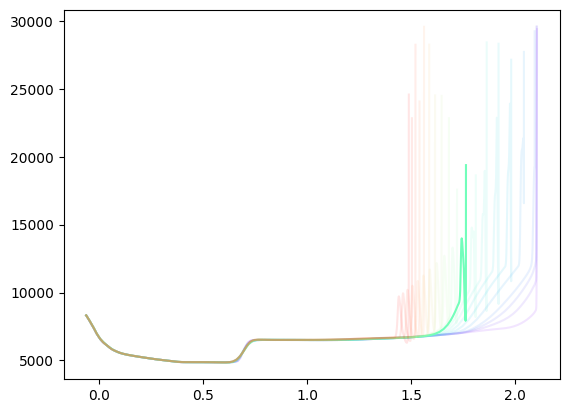

In [11]:
cmap = mpl.colormaps['rainbow']
colors = cmap(np.linspace(0, 1, 20))
ind = simulations[10]['Si_max_t']
num = 0
print(simulations[num]['name'])
for ind in range(20):
    alpha = 1 if (ind-simulations[num]['Si_max_t'])==0 else 0.1
    _ = plt.plot(simulations[num]['height'][ind]*1e-6, simulations[10]['temperature'][ind], 
                color=colors[ind], alpha=alpha)
    

In [177]:
aa['temperature'][9]

array([       nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        

In [162]:
aa['temperature'].shape, aa['log_tau_500'].shape

((41, 299), (41, 299))

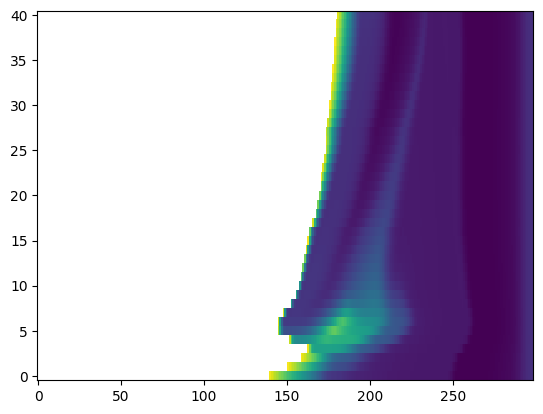

In [163]:
aa = simulations[10]
plt.imshow(aa['temperature'])

In [167]:
for i in aa['temperature']:
    print(np.sum(np.isfinite(i)))

159
148
140
136
147
154
154
151
146
143
141
140
139
138
137
136
135
133
131
130
129
128
128
127
126
125
125
125
124
123
123
122
122
121
121
120
120
120
119
119
118


In [144]:
simulations[10]['Si_spec'].shape

(42, 77)

In [146]:
simulations[10].keys()

dict_keys(['name', 'path', 'Si_wv', 'Si_t', 'Si_spec', 'Si_max_t', 'Mg_wv', 'Mg_t', 'Mg_spec', 'ltau_500', 'height', 'temperature', 'vz', 'mg_spec', 'log_tau_500'])

In [150]:
simulations[10]['Si_wv']

array([1401.782, 1401.808, 1401.834, 1401.86 , 1401.886, 1401.912,
       1401.938, 1401.964, 1401.99 , 1402.016, 1402.042, 1402.068,
       1402.094, 1402.12 , 1402.146, 1402.172, 1402.198, 1402.224,
       1402.25 , 1402.276, 1402.302, 1402.328, 1402.354, 1402.38 ,
       1402.406, 1402.432, 1402.458, 1402.484, 1402.51 , 1402.536,
       1402.562, 1402.588, 1402.614, 1402.64 , 1402.666, 1402.692,
       1402.718, 1402.744, 1402.77 , 1402.796, 1402.822, 1402.848,
       1402.874, 1402.9  , 1402.926, 1402.952, 1402.978, 1403.004,
       1403.03 , 1403.056, 1403.082, 1403.108, 1403.134, 1403.16 ,
       1403.186, 1403.212, 1403.238, 1403.264, 1403.29 , 1403.316,
       1403.342, 1403.368, 1403.394, 1403.42 , 1403.446, 1403.472,
       1403.498, 1403.524, 1403.55 , 1403.576, 1403.602, 1403.628,
       1403.654, 1403.68 , 1403.706, 1403.732, 1403.758], dtype='>f8')

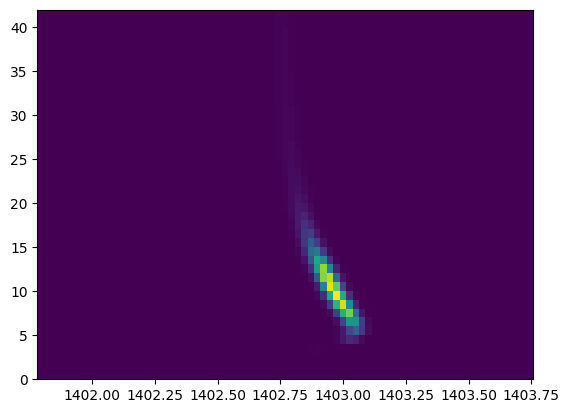

In [151]:
plt.imshow(simulations[10]['Si_spec'], extent=[simulations[10]['Si_wv'][0], simulations[10]['Si_wv'][-1], 0, 42])

In [47]:
aa, bb

([False, False, False, False], [True, True, False, False])

In [39]:
'time' in 'timet'

True

In [234]:
si_data['sp_time'].shape, si_data['wvl'].shape

((601, 308), (308,))

In [251]:
idx_siwv = (si_data.wvl > 1400.77) & (si_data.wvl < 1404.77)

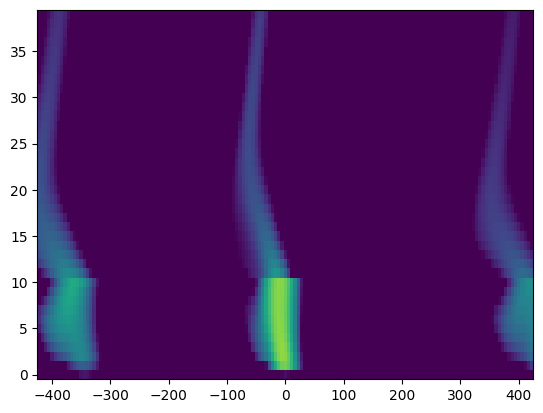

In [252]:
plt.pcolormesh((si_data.wvl[idx_siwv]-1402.77)/1402.77*3e5, si_data['time'][0:40], np.log10(si_data.sp_time[0:40, idx_siwv]), vmin=-1, vmax=4)

In [ ]:
wv = np.array(ray['wavelength'])

intensity = np.squeeze(ray['intensity'])

idx = (wv > 279.5) & (wv < 280.5)

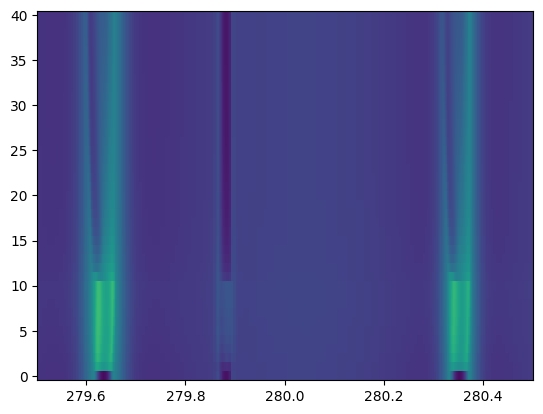

In [249]:
plt.pcolormesh(wv[idx], np.arange(41), np.log10(intensity[:, idx]), vmin=-10, vmax=-6)

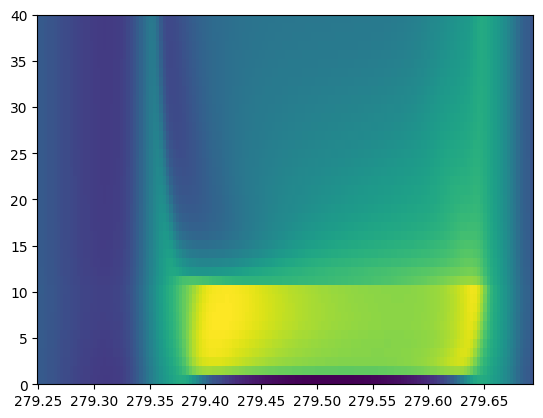

In [203]:
plt.imshow(np.squeeze(np.log10(ray['intensity'][:, 0, 250:400])), extent=[wv[250], wv[400], 0, 40])

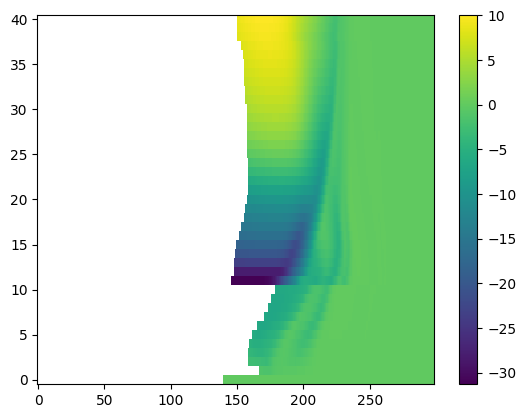

In [131]:
dum = plt.imshow(velocity_z*1e-3)
plt.gcf().colorbar(dum)

In [126]:
ray.keys()

<KeysViewHDF5 ['nx', 'ny', 'nz', 'nwave', 'wavelength_selected', 'intensity', 'tau_one_height', 'chi', 'source_function', 'Jlambda', 'scattering', 'wavelength', 'wavelength_indices']>

In [2]:
import h5py
sim_data = h5py.File("/Users/khcho/Desktop/IRIS-moss-main/simulation/rh_output_kh/15Mm_1MK_5kev_plage/output/output_indata.ncdf", 'r')

In [3]:
ray = h5py.File("/Users/khcho/Desktop/IRIS-moss-main/simulation/rh_output_kh/15Mm_1MK_5kev_plage/output/output_ray.ncdf", 'r')

In [4]:
ray.keys()

<KeysViewHDF5 ['nx', 'ny', 'nz', 'nwave', 'wavelength_selected', 'intensity', 'tau_one_height', 'chi', 'source_function', 'Jlambda', 'scattering', 'wavelength', 'wavelength_indices']>

In [5]:
wavelength_indices = np.array(ray['wavelength_indices'])
wavelength_selected = np.array(ray['wavelength'])[wavelength_indices]
wavelength_selected

array([279.50622627, 279.51628586, 279.52549798, 279.53393554,
       279.54166519, 279.54874785, 279.5552392 , 279.55620945,
       279.5611901 , 279.56664706, 279.57165259, 279.57624552,
       279.58046137, 279.58433257, 279.58788879, 279.59115713,
       279.59416235, 279.5969271 , 279.59947207, 279.60181617,
       279.60397669, 279.60596942, 279.60780879, 279.60950802,
       279.61107914, 279.6125332 , 279.61388025, 279.61512952,
       279.6162894 , 279.6173676 , 279.61837114, 279.61930644,
       279.62017938, 279.62099533, 279.62175918, 279.62247542,
       279.62314815, 279.62354828, 279.62378111, 279.62437772,
       279.62494112, 279.62547415, 279.62597943, 279.62645935,
       279.6269161 , 279.62735165, 279.62776785, 279.62816635,
       279.62854868, 279.62891623, 279.62927027, 279.62961196,
       279.62994237, 279.63026246, 279.63057313, 279.63087518,
       279.63116936, 279.63145634, 279.63173674, 279.63201114,
       279.63228004, 279.63254392, 279.63280321, 279.63

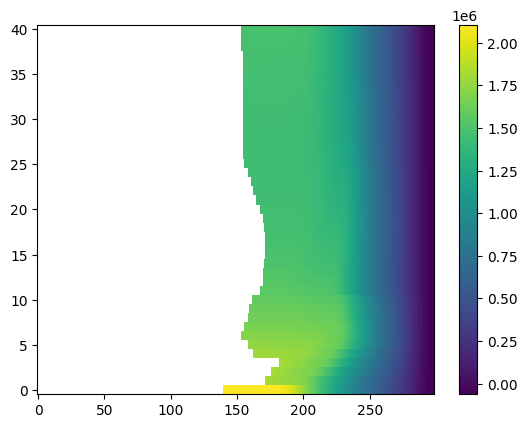

In [46]:
height0 = np.array((sim_data['atmos']['height']))[:, 0, :]
height = np.where(height0 > 1e36, np.nan, height0)
height1 = np.copy(height0)
for i, he in enumerate(height1):
    h_real = height0[i][height[i] < 1e36]
    height1[i] = np.where(height0[i] > 1e36, 2*h_real[0]-h_real[1], height0[i])
p01 = plt.imshow(np.squeeze(height))
plt.gcf().colorbar(p01)

In [49]:
idx_500 = np.argmin(abs(wavelength_selected - 500))
idx_500

np.int64(346)

In [50]:
chi_500 = np.array(ray['chi'])[:, 0, :, idx_500]
chi_500.shape

(41, 299)

In [86]:
from scipy import integrate
tau_500 = integrate.cumulative_trapezoid(chi_500, x=-height1, initial=0)
# tau_500 = np.hstack([np.full(chi_500.shape[0], 0)[:, None], tau_500])
log_tau_500 = np.log10(tau_500)

/var/folders/1n/h1tn4xf511bdd_rqlgcl4kqw000mt3/T/ipykernel_23775/3854004516.py:4: RuntimeWarning: divide by zero encountered in log10
  log_tau_500 = np.log10(tau_500)


In [66]:
temperature = sim_data['atmos']['temperature'][:, 0, :]
temperature = np.where(temperature > 1e35, np.nan, temperature)

[Text(0.5, 0, '$\\log \\tau_{500}$'), Text(0, 0.5, 'Height (km)')]

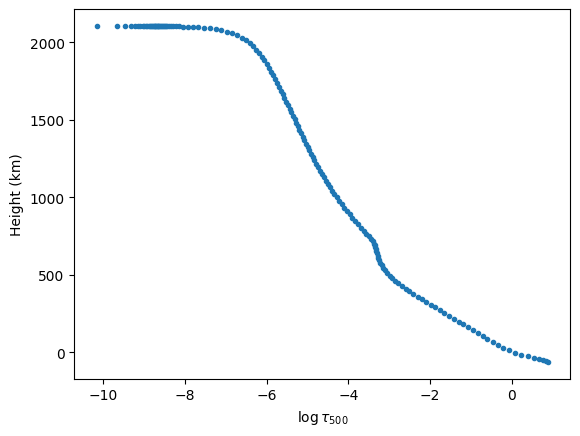

In [105]:
plt.plot(log_tau_500[0], height[0]*1e-3, '.')
plt.gca().set(xlabel=r'$\log \tau_{500}$', ylabel='Height (km)')
# plt.plot(plt.gca().get_xlim(), [0]*2)
# plt.gca().set(xlim=[-10, -1])

[Text(0, 0.5, 'Temperature (K)'), Text(0.5, 0, '$\\log \\tau_{500}$')]

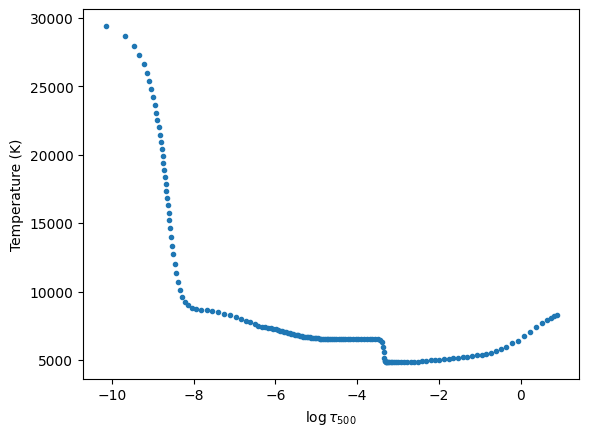

In [106]:
plt.plot(log_tau_500[0], temperature[0], '.')
plt.gca().set(ylabel=r'Temperature (K)', xlabel=r'$\log \tau_{500}$')
# plt.plot(plt.gca().get_xlim(), [0]*2)
# plt.gca().set(xlim=[-10, -1])

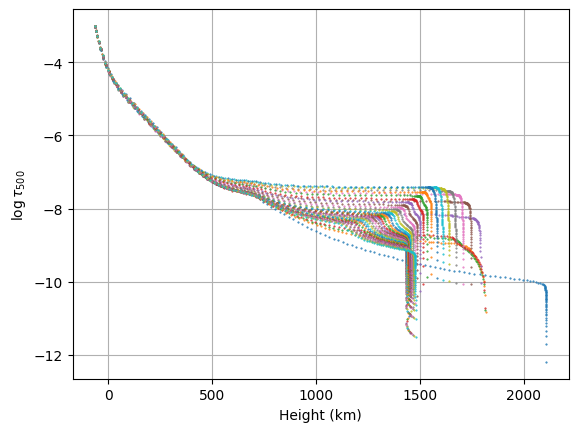

In [141]:
for i in range(40):
    plt.plot(height[i], log_tau_500[i], '.', ms=1)
plt.gca().set(xlabel='Height (km)', ylabel=r'$\log \tau_{500}$')
plt.grid()

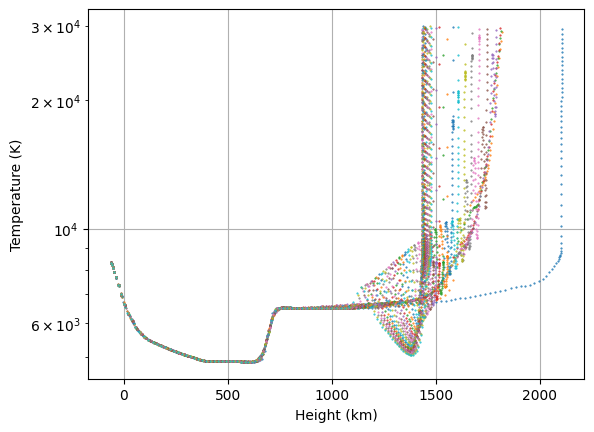

In [143]:
for i in range(40):
    plt.plot(height[i], temperature[i], '.', ms=1)
plt.gca().set(xlabel='Height (km)', ylabel='Temperature (K)', yscale='log')
plt.grid()

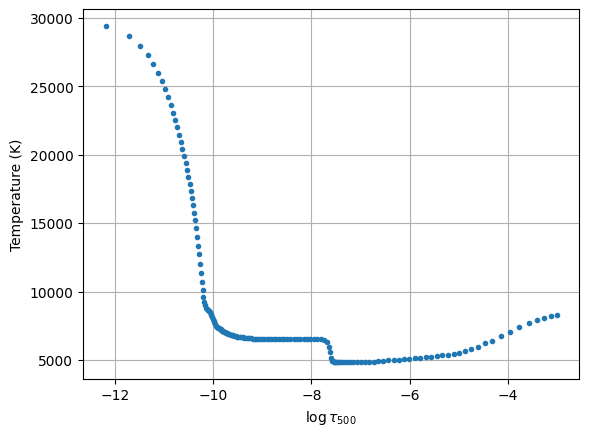

In [139]:
plt.plot(log_tau_500[0], temperature[0], '.')
plt.gca().set(xlabel=r'$\log \tau_{500}$', ylabel='Temperature (K)')
plt.grid()

In [103]:
np.sum(chi, axis=1)

array([0.00110751, 0.00109956, 0.00108148, 0.00106479, 0.00105759,
       0.0010482 , 0.00104856, 0.0010527 , 0.00105798, 0.00106185,
       0.00106585, 0.00107937, 0.00108038, 0.0010787 , 0.00107602,
       0.001074  , 0.00107221, 0.00107137, 0.00107056, 0.00107029,
       0.00107041, 0.00107092, 0.00107126, 0.00107083, 0.00107097,
       0.0010759 , 0.00107678, 0.00107748, 0.00107783, 0.00107729,
       0.00107736, 0.0010779 , 0.00107858, 0.00107914, 0.00107988,
       0.00108068, 0.00108128, 0.00108194, 0.00108267, 0.00108342,
       0.00108406], dtype=float32)

In [72]:
for key in list(sim_data.keys()):
    print(f'{key}, {np.array(sim_data[key]).shape}')
    try:
        for key_ in list(sim_data[key].keys()):
            print(f'    {key_}, {np.array(sim_data[key][key_]).shape}')
    except:
        pass

input, (0,)
atmos, (13,)
    nhydr, (6,)
    nelements, (99,)
    nrays, (5,)
    temperature, (41, 1, 299)
    velocity_z, (41, 1, 299)
    height, (41, 1, 299)
    element_weight, (99,)
    element_abundance, (99,)
    element_id, (99, 30)
    muz, (5,)
    wmu, (5,)
    x, (41,)
    y, (1,)
mpi, (15,)
    nprocesses, (4,)
    niterations, (1500,)
    xnum, (41,)
    ynum, (1,)
    task_map, (41, 1)
    task_number, (41, 1)
    iterations, (41, 1)
    convergence, (41, 1)
    delta_max, (41, 1)
    z_cut, (41, 1)
    ntasks, (4,)
    hostname, (4, 30)
    starting_time, (4, 30)
    finish_time, (4, 30)
    delta_max_history, (41, 1, 1500)
nx, (41,)
ny, (1,)
nz, (299,)
strlen, (30,)


In [66]:
for key in list(sim_data['atmos'].keys()):
    print(f'{key}, {np.array(sim_data['atmos'][key]).shape}')

nhydr, (6,)
nelements, (99,)
nrays, (5,)
temperature, (41, 1, 299)
velocity_z, (41, 1, 299)
height, (41, 1, 299)
element_weight, (99,)
element_abundance, (99,)
element_id, (99, 30)
muz, (5,)
wmu, (5,)
x, (41,)
y, (1,)
